# Results of 3-tensor plot with real measurements: experiment and results

In [1]:
import matplotlib.pyplot as plt

import os
import json

plt.rcParams.update({
    'xtick.labelsize': 16,       # Tamaño de fuente de los ticks del eje X
    'ytick.labelsize': 16,       # Tamaño de fuente de los ticks del eje Y
    #'xtick.color': 'blue',       # Color de los ticks del eje X
    #'ytick.color': 'green',      # Color de los ticks del eje Y
    'axes.titlesize': 16,        # Tamaño de fuente del título de los ejes
    'axes.labelsize': 14,
    'legend.fontsize':16# Tamaño de fuente de las etiquetas de los ejes
    #'axes.labelcolor': 'purple', # Color de las etiquetas de los ejes
})


### Read results

In [2]:
files_100sampling = {}
directory_100sampling = 'results/100_sampling'

for file in os.listdir(directory_100sampling):
    if file.endswith('.json') :#and  'DONTUSE' not in file:
        full_path = os.path.join(directory_100sampling, file)
        with open(full_path, 'r', encoding='utf-8') as f:
            filename = os.path.splitext(file)[0]
            files_100sampling[filename] = json.load(f)

files_keys_100sampling = list(files_100sampling.keys())

In [3]:
len(files_keys_100sampling)

21

In [4]:
files_1000sampling = {}
directory_1000sampling = 'results/1000_sampling'

for file in os.listdir(directory_1000sampling):
    if file.endswith('.json') :#and  'DONTUSE' not in file:
        full_path = os.path.join(directory_1000sampling, file)
        with open(full_path, 'r', encoding='utf-8') as f:
            filename = os.path.splitext(file)[0]
            files_1000sampling[filename] = json.load(f)

files_keys_1000sampling = list(files_1000sampling.keys())

In [5]:
len(files_keys_1000sampling)

21

### Plot results

In [11]:
probability_differences_100sampling = {}
probability_differences_1000sampling = {}

for (filekey,file_100sampling),(_,file_1000sampling) in zip(files_100sampling.items(),files_1000sampling.items()):
    if filekey == 'conf_jrpInitConf3_circuitConf2':
        print('TODO: ARREGLAR ESTE SKIP')
        continue
    print(f'in {filekey}')
    probability_differences_100sampling[filekey] = {}
    probability_differences_1000sampling[filekey] = {}
    
    keys_100sampling = file_100sampling['theoretical_probabilities_for_xMinAproxRatio_zNMeasurements'].keys()
    keys_1000sampling = file_1000sampling['theoretical_probabilities_for_xMinAproxRatio_zNMeasurements'].keys()
    for key1,key2 in zip(keys_100sampling,keys_1000sampling):
        #key = key1
        #print(f'in {key2}')
        experimental_probability = file_100sampling['experimental_probabilities_for_xMinAproxRatio_zNMeasurements'][key1]
        theoretical_probability = file_100sampling['theoretical_probabilities_for_xMinAproxRatio_zNMeasurements'][key1]
        probability_difference =  theoretical_probability - experimental_probability
        probability_differences_100sampling[filekey][key1] = probability_difference

        experimental_probability = file_1000sampling['experimental_probabilities_for_xMinAproxRatio_zNMeasurements'][key2]
        theoretical_probability = file_1000sampling['theoretical_probabilities_for_xMinAproxRatio_zNMeasurements'][key2]
        probability_difference =  theoretical_probability - experimental_probability
        probability_differences_1000sampling[filekey][key2] = probability_difference
        

in conf_jrpInitConf0_circuitConf0
in conf_jrpInitConf0_circuitConf1
in conf_jrpInitConf0_circuitConf2
in conf_jrpInitConf1_circuitConf0
in conf_jrpInitConf1_circuitConf1
in conf_jrpInitConf1_circuitConf2
in conf_jrpInitConf2_circuitConf0_DONTUSE
in conf_jrpInitConf2_circuitConf1_DONTUSE
in conf_jrpInitConf2_circuitConf2
in conf_jrpInitConf3_circuitConf0
in conf_jrpInitConf3_circuitConf1
TODO: ARREGLAR ESTE SKIP
in conf_jrpInitConf4_circuitConf0
in conf_jrpInitConf4_circuitConf1
in conf_jrpInitConf4_circuitConf2
in conf_jrpInitConf5_circuitConf0
in conf_jrpInitConf5_circuitConf1
in conf_jrpInitConf5_circuitConf2
in conf_jrpInitConf6_circuitConf0
in conf_jrpInitConf6_circuitConf1
in conf_jrpInitConf6_circuitConf2


conf_jrpInitConf0_circuitConf0


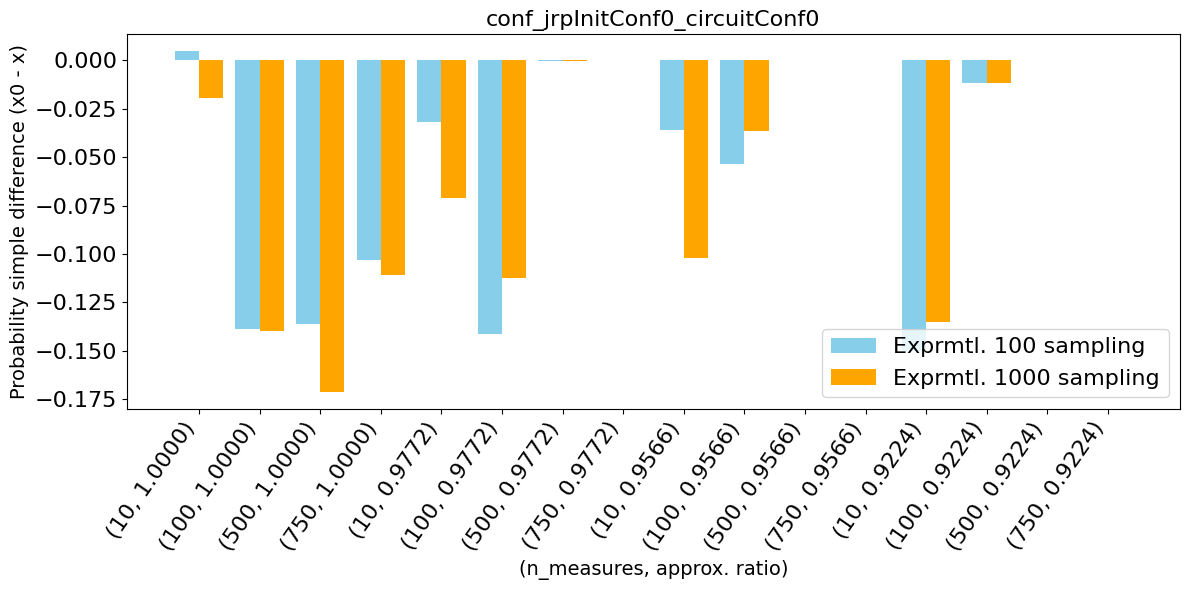

conf_jrpInitConf0_circuitConf1


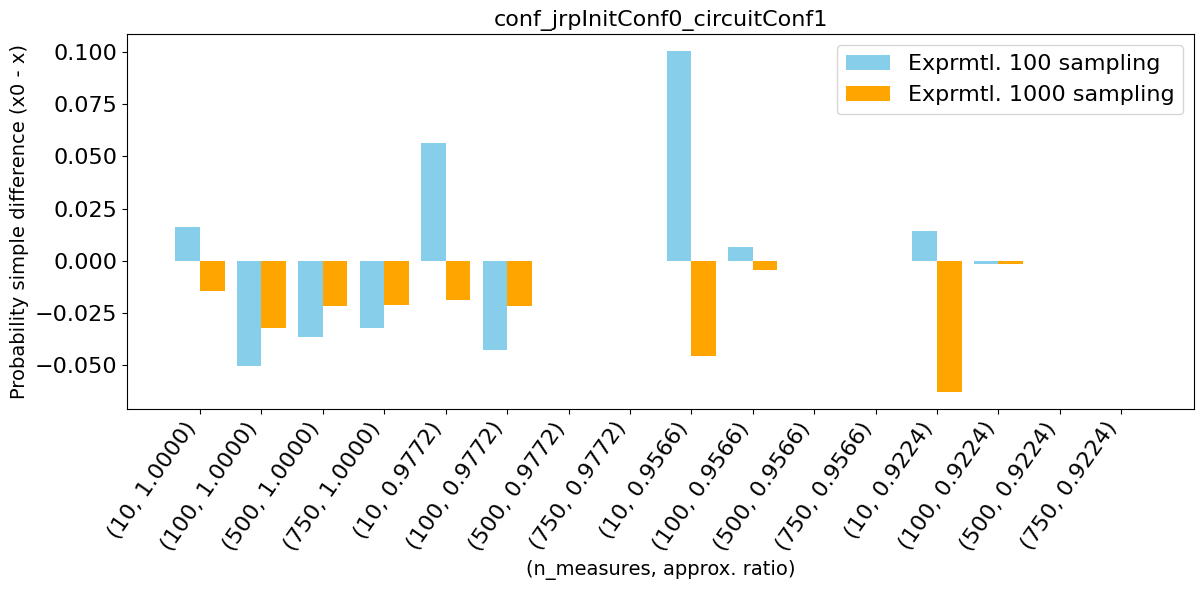

conf_jrpInitConf0_circuitConf2


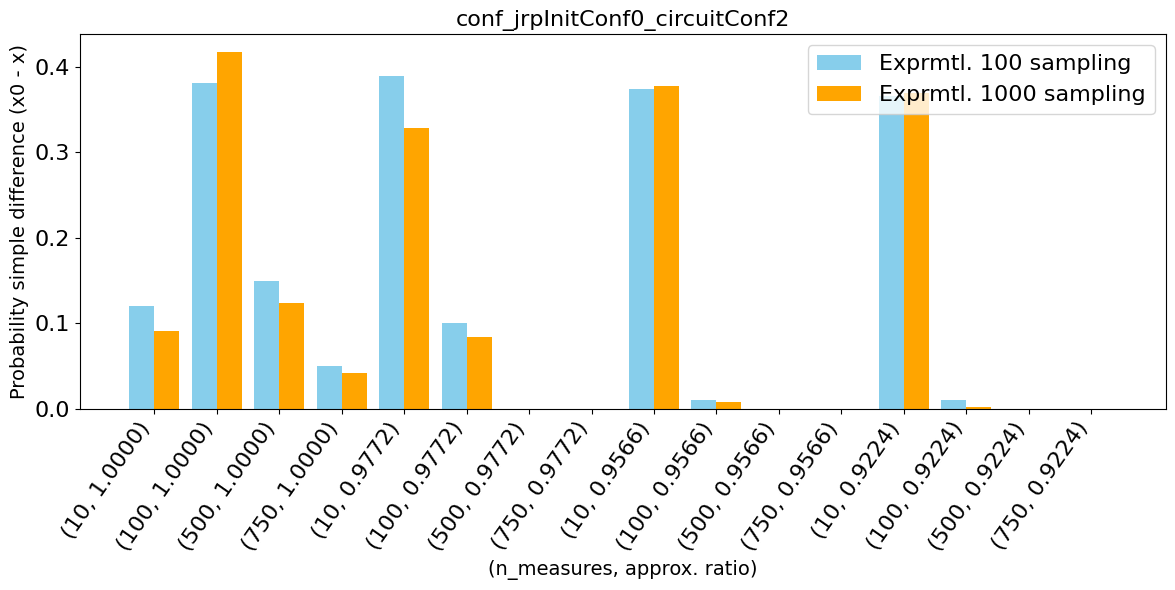

conf_jrpInitConf1_circuitConf0


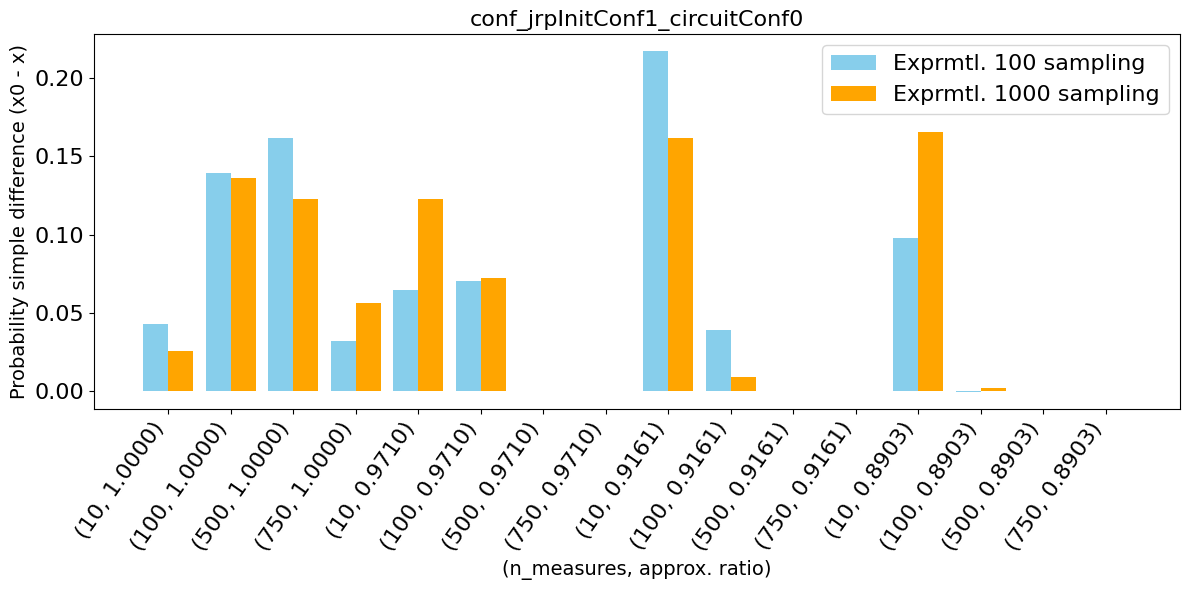

conf_jrpInitConf1_circuitConf1


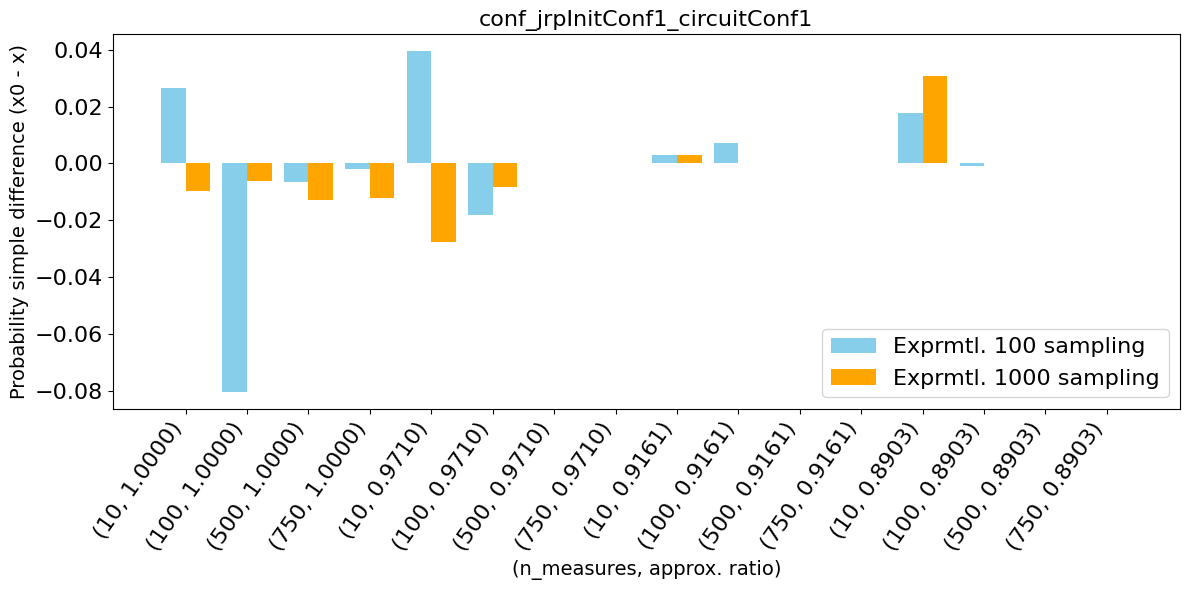

conf_jrpInitConf1_circuitConf2


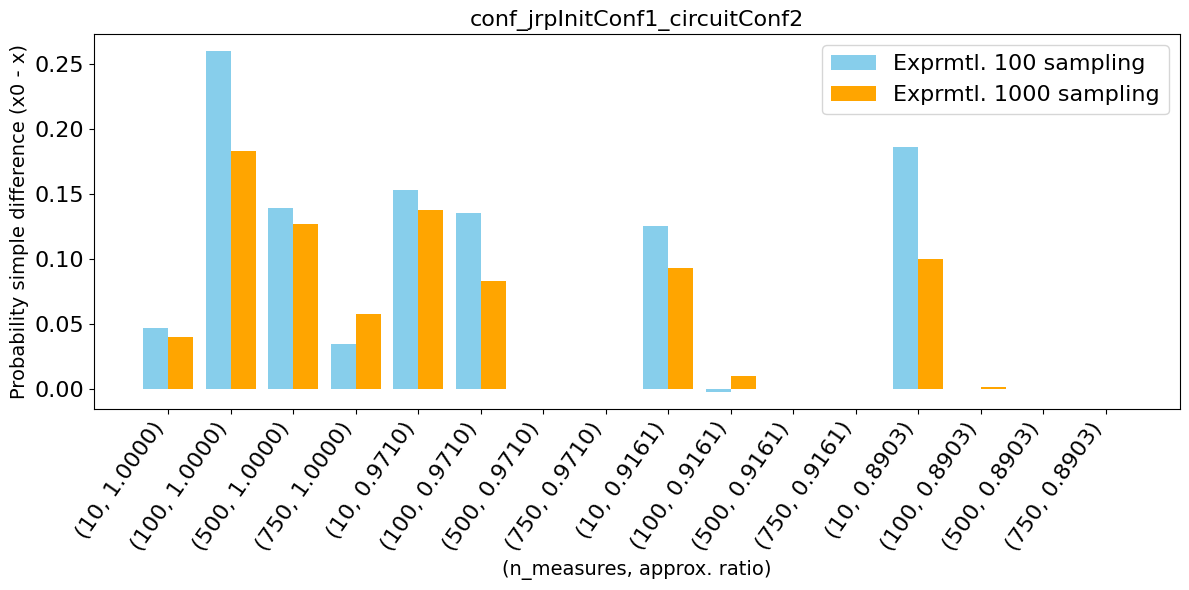

conf_jrpInitConf2_circuitConf0_DONTUSE
Las claves de conf_jrpInitConf2_circuitConf0_DONTUSE y conf_jrpInitConf2_circuitConf0_DONTUSE no coinciden, saltando...
conf_jrpInitConf2_circuitConf1_DONTUSE
Las claves de conf_jrpInitConf2_circuitConf1_DONTUSE y conf_jrpInitConf2_circuitConf1_DONTUSE no coinciden, saltando...
conf_jrpInitConf2_circuitConf2


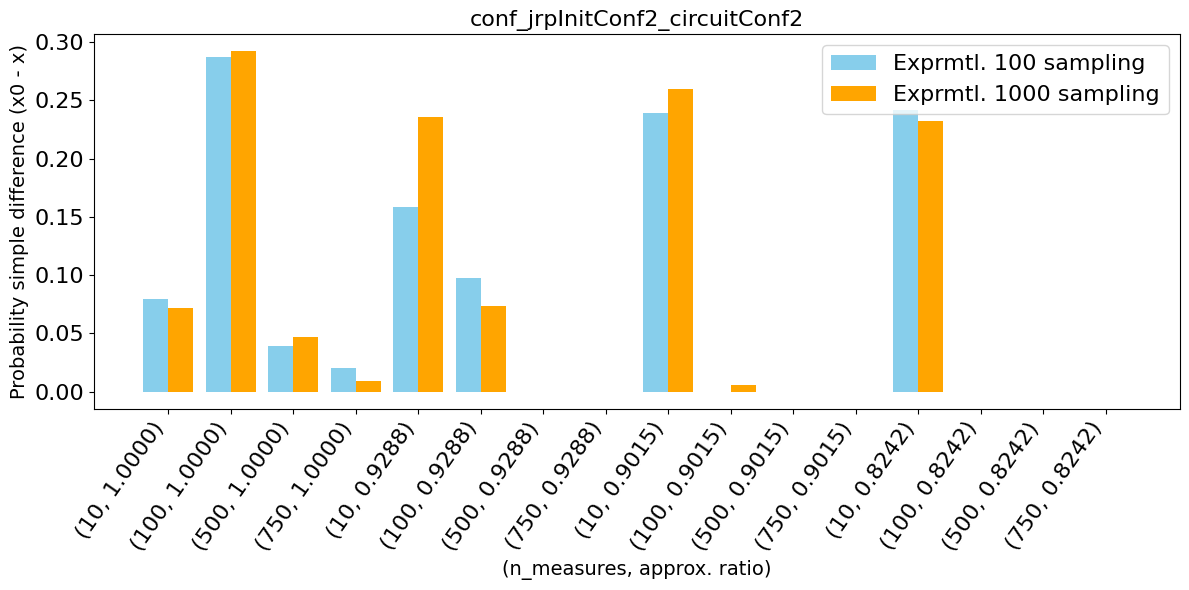

conf_jrpInitConf3_circuitConf0


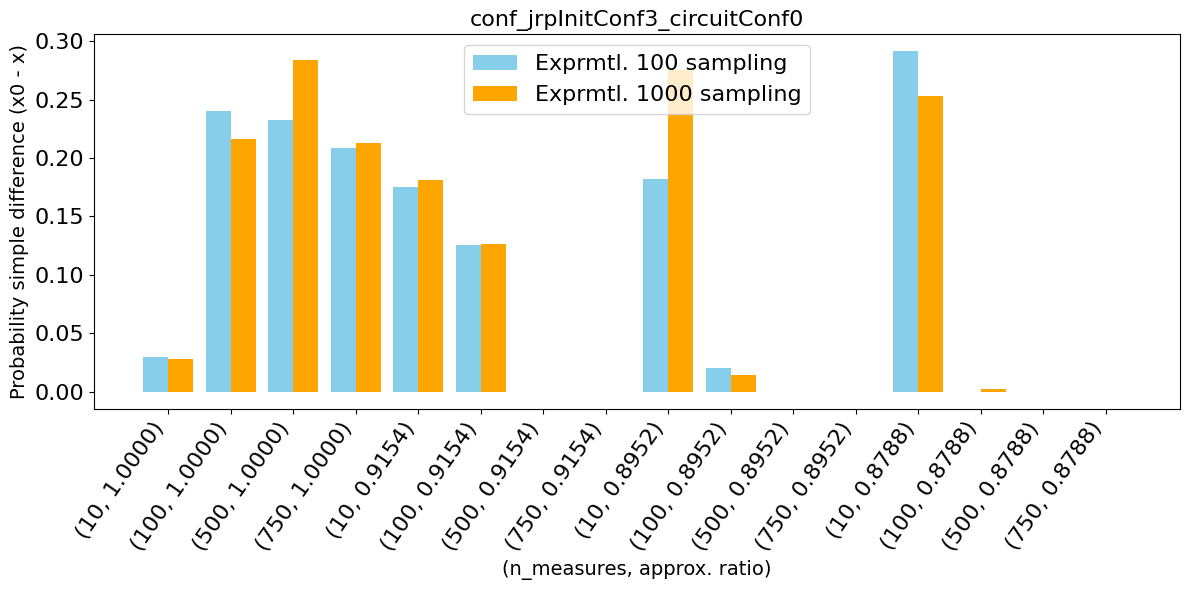

conf_jrpInitConf3_circuitConf1


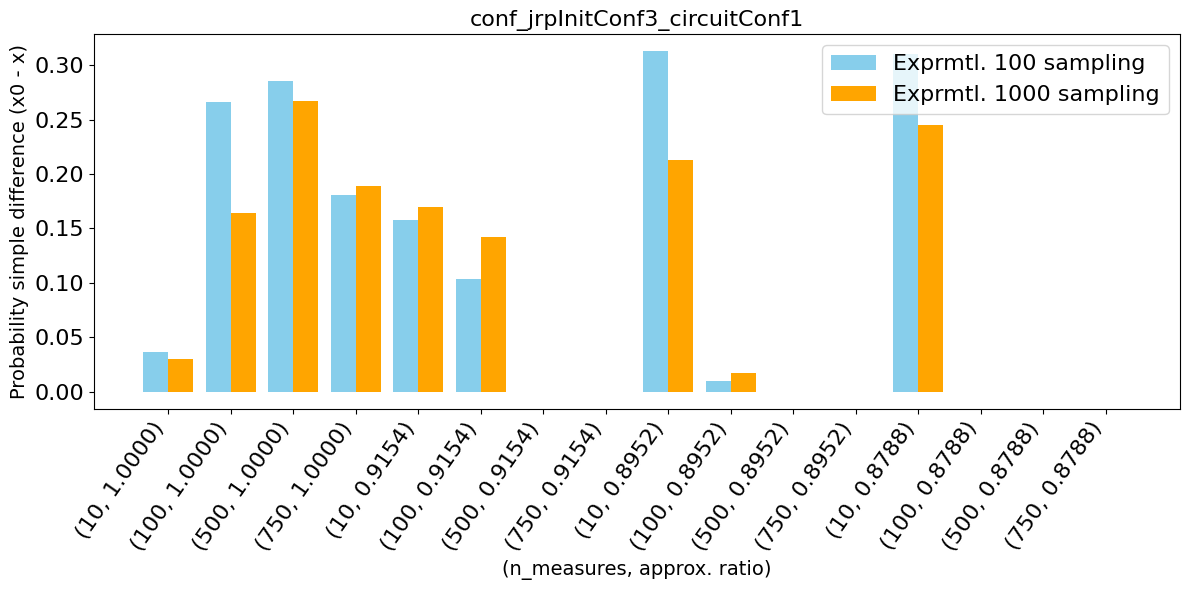

conf_jrpInitConf4_circuitConf0


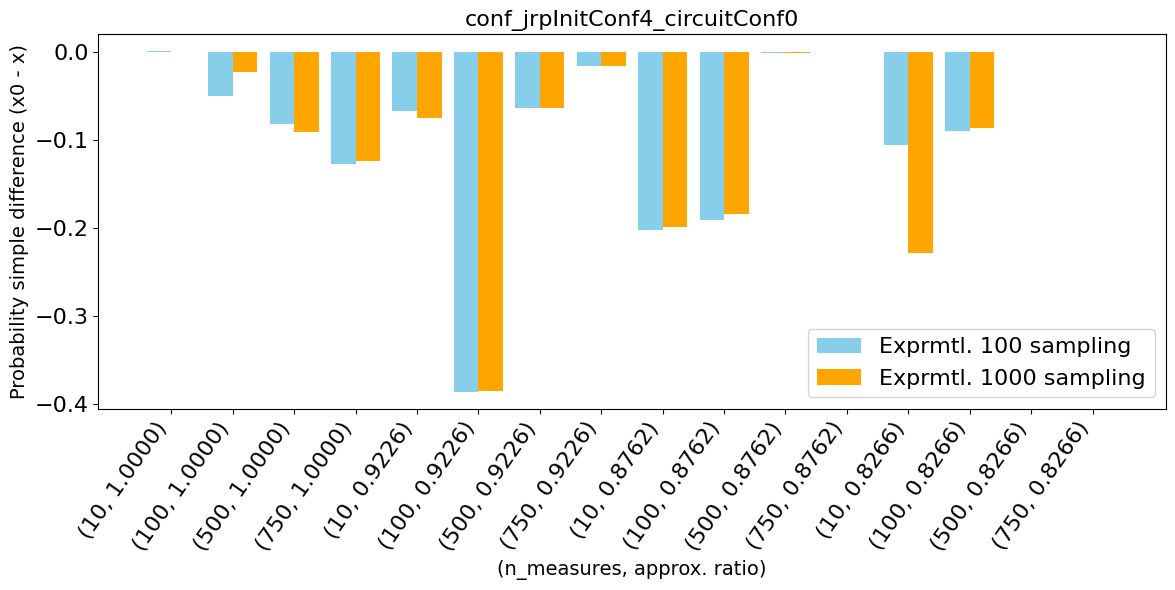

conf_jrpInitConf4_circuitConf1


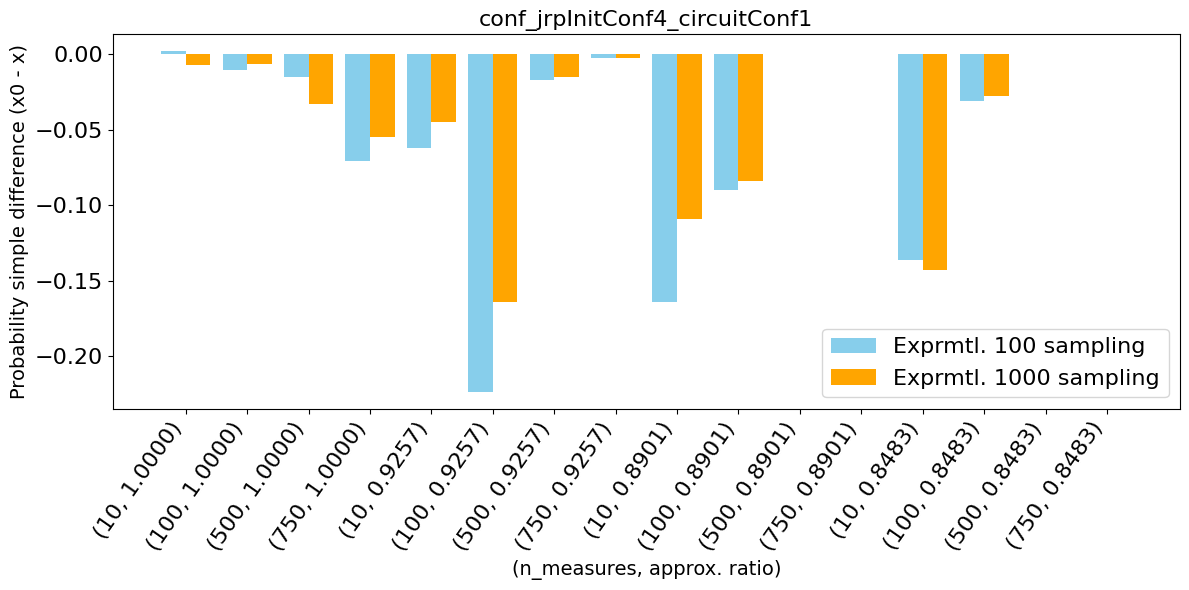

conf_jrpInitConf4_circuitConf2


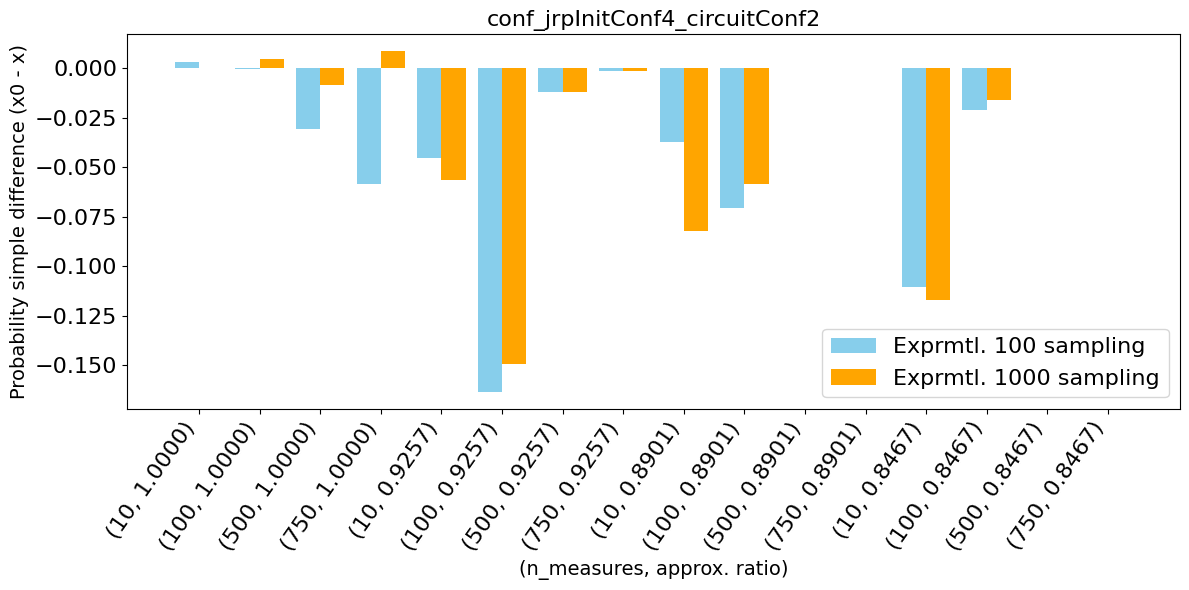

conf_jrpInitConf5_circuitConf0


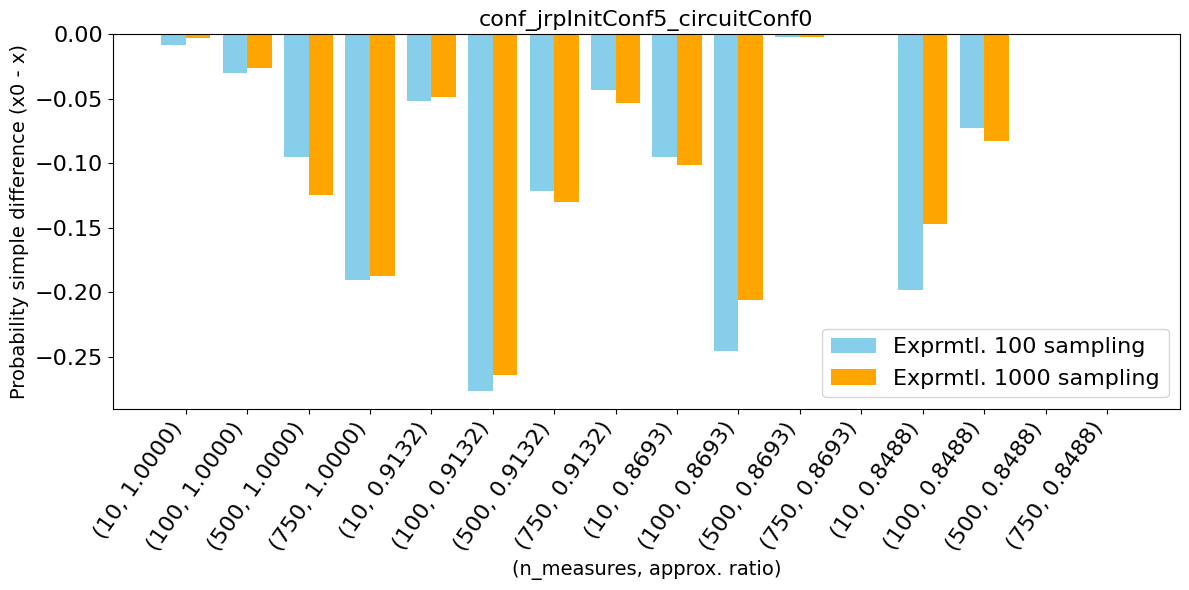

conf_jrpInitConf5_circuitConf1


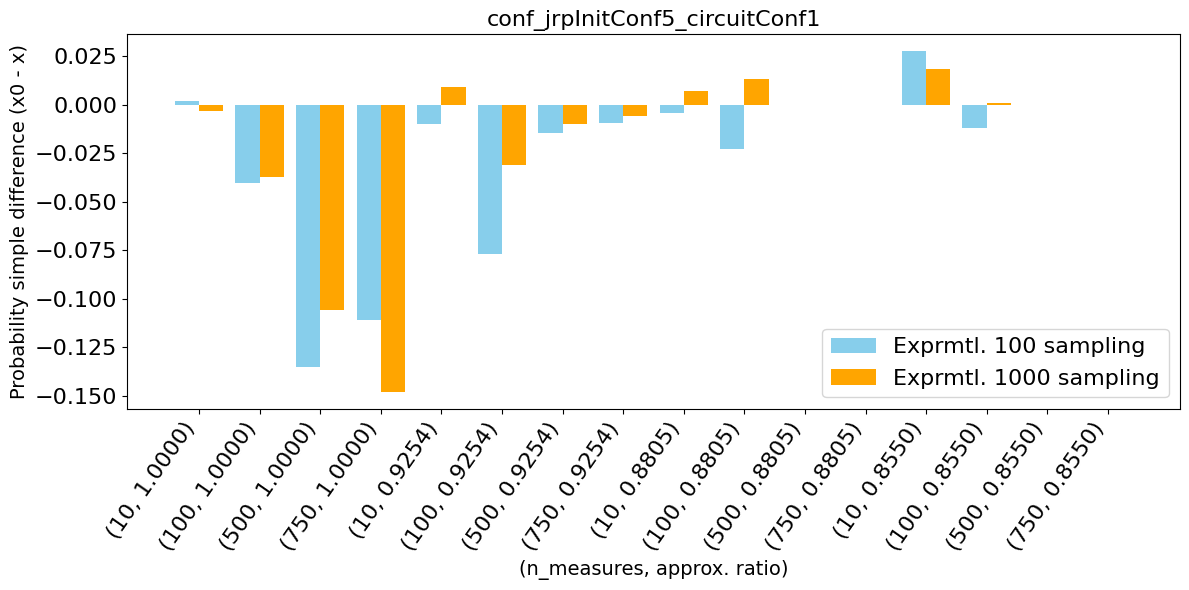

conf_jrpInitConf5_circuitConf2


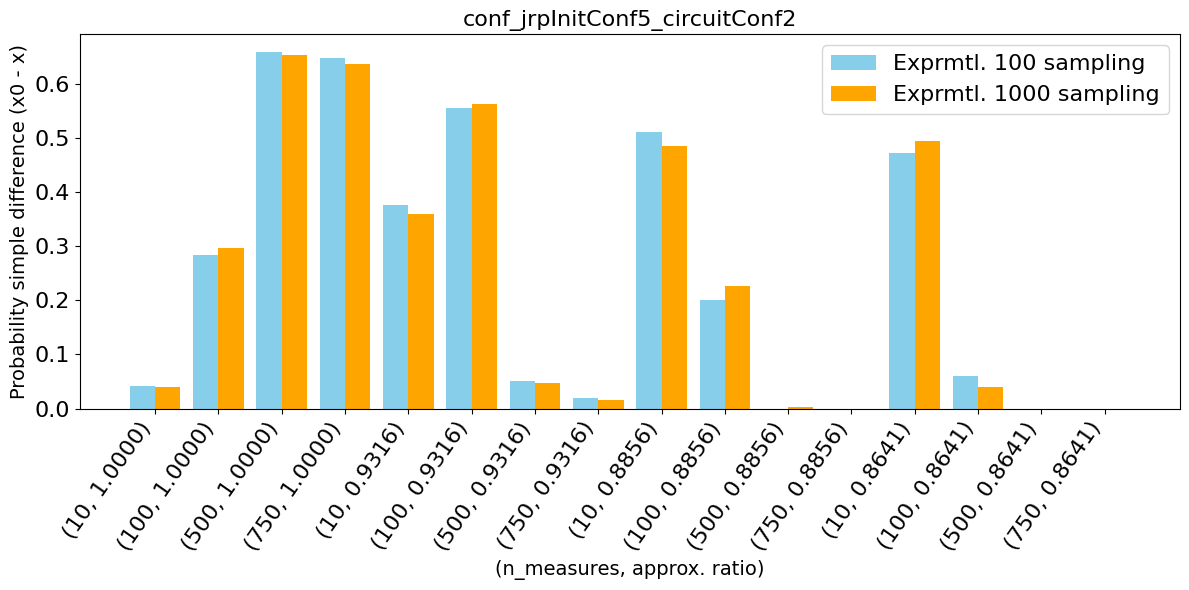

conf_jrpInitConf6_circuitConf0


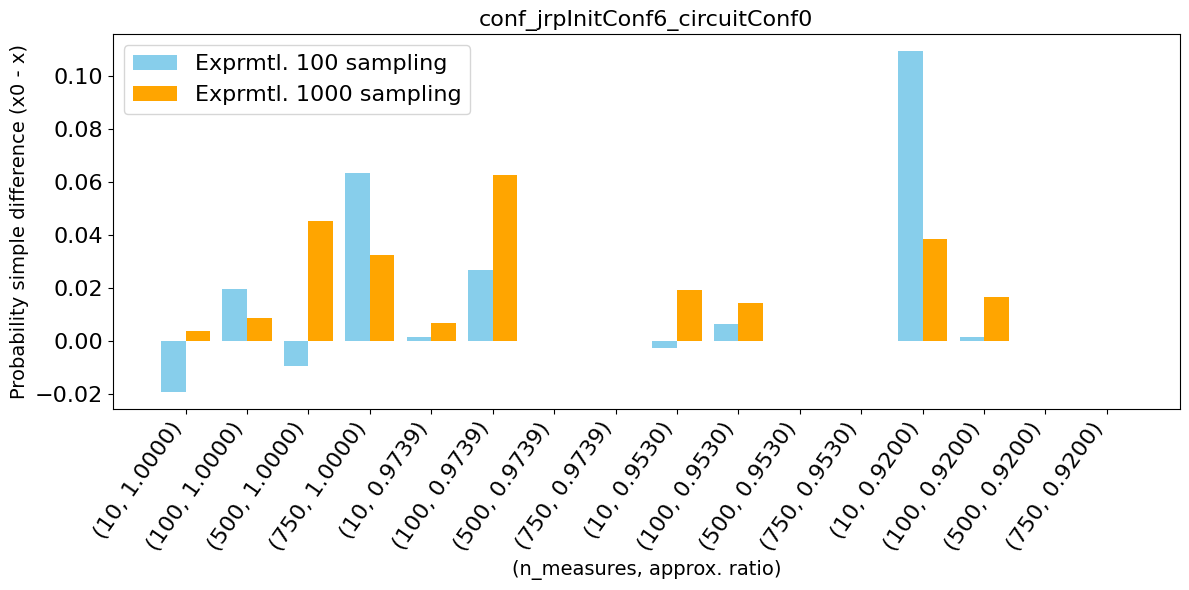

conf_jrpInitConf6_circuitConf1


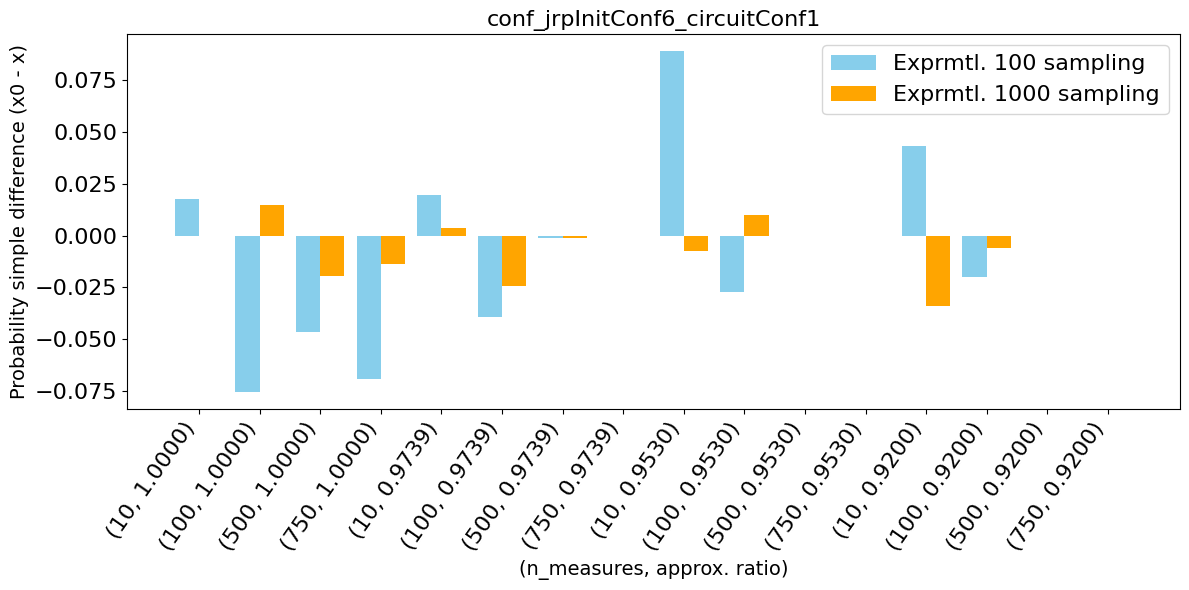

conf_jrpInitConf6_circuitConf2


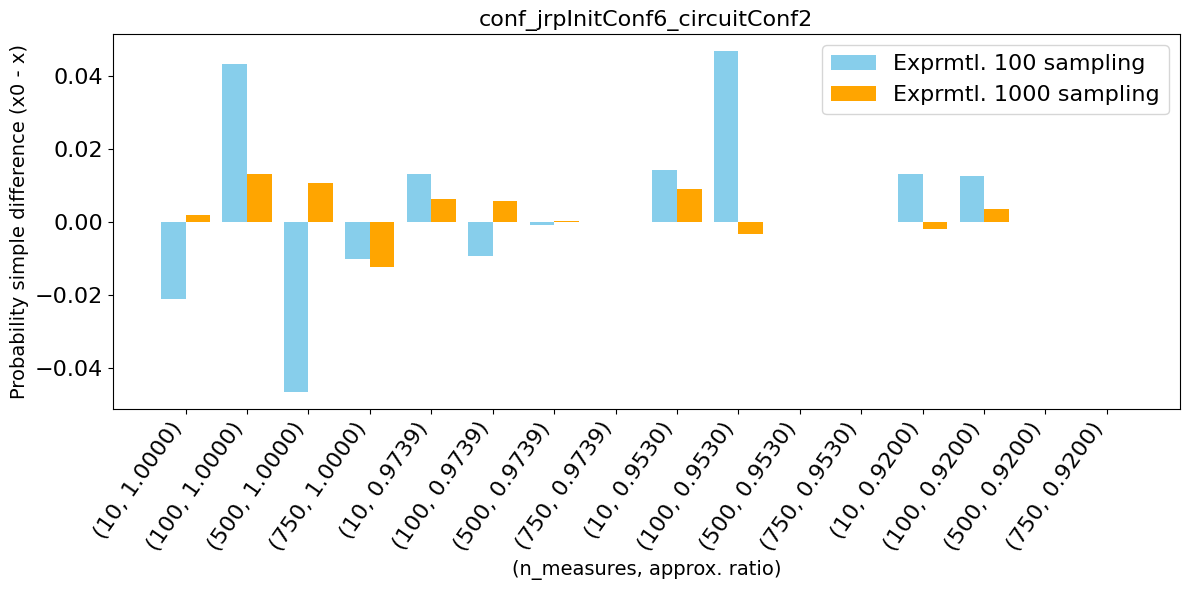

In [7]:
# Iterar sobre los conjuntos de datos de data y data2
for (set_name1, sub_dict1), (set_name2, sub_dict2) in zip(probability_differences_100sampling.items(), probability_differences_1000sampling.items()):
    # Convertir las claves de cadena a tuplas
    keys1 = [eval(k) for k in sub_dict1.keys()]
    keys2 = [eval(k) for k in sub_dict2.keys()]
    print(set_name1)
    # Asegurarse de que las claves coincidan
    if keys1 != keys2:
        print(f"Las claves de {set_name1} y {set_name2} no coinciden, saltando...")
        continue

    values1 = list(sub_dict1.values())
    values2 = list(sub_dict2.values())
    
    # Crear etiquetas de eje x
    x_labels = [f'({k[0]}, {k[1]:.4f})' for k in keys1]
    x = range(len(x_labels))  # Índices para las barras

    # Crear el gráfico
    plt.figure(figsize=(12, 6))
    plt.bar(x, values1, width=0.4, label=set_name1, align='center', color='skyblue')
    plt.bar([i + 0.4 for i in x], values2, width=0.4, label=set_name2, align='center', color='orange')
    plt.xticks([i + 0.2 for i in x], x_labels, rotation=55, ha='right')
    plt.title(f'{set_name1}')
    plt.xlabel('(n_measures, approx. ratio)')
    plt.ylabel('Probability simple difference (x0 - x)')
    plt.legend(labels=['Exprmtl. 100 sampling', 'Exprmtl. 1000 sampling'])
    plt.tight_layout()
    
    # Guardar o mostrar el gráfico
    plt.savefig(f'results/imgs/{set_name1}_bar_plot.png')  # Guarda el gráfico como archivo
    plt.show()  # O muestra el gráfico en pantalla

### Things to consider

* We can think about measuring a QAOA ansats as a Multinomial distribution. The process of estimating the probability of measuring a particular bitstring is though as the proportion estimator of the distribution. We need to have, for each possible bitstring, a big enough sample to correctly approximate its estimated proportion.
* We are hardware-limited for the proportion estimation, since the amount of bitstring increase exponentially. For this tests, we decide an amount of $M \cdot n\_bitstrings$ shots a particular ansatzs. the constant $M$ is a value that configure how many shots will have a sampling for estimating each proportion. So, for example, if $M=1000$ and $n\_bitstring = 25$, each possible bitstring will have $1000$ shots for estimating its proportion, having a total of $1000 \cdot 25 = 25000$ shots for the complete test.
* We also decide a size multiplier $S$, which configure how much of the total amount of possible states will be used for the calculations.
* I got the variances, so we can calculate an error involved or something like that.